# 06. Frozen official unseen-airfoil test

## Publication decision fixed before test access

Notebook 05 completed and audited all decisive validation experiments. The final architecture is now frozen as **`no_alignment`**, the geometry-conditioned spectral model with iterative local refinement using a Cartesian stencil.

The choice is based only on development validation evidence:

| Configuration | Validation scaled L1, mean ± SD | Decision |
|---|---:|---|
| `no_alignment` | **0.003655 ± 0.000077** | Frozen final model |
| `proposed` | 0.003661 ± 0.000070 | Alignment did not improve the mean |
| `conv_refiner_control` | 0.003695 ± 0.000061 | Generic convolutional control |
| `fno` | 0.004309 ± 0.000030 | Strongest matched baseline by validation L1 |
| `modern_unet` | 0.004365 ± 0.000017 | Matched CNN baseline |
| `dfp_original` | 0.004846 ± 0.000159 | Historical CNN baseline |

The validation evidence supports these bounded statements:

- Iterative local refinement improves the validation errors relative to removing refinement.
- The frozen model substantially outperforms the matched DFP, U-Net, and FNO baselines on development validation.
- The directional refiner improves pressure error relative to a parameter-matched generic convolutional control, but its overall L1 and velocity advantages are not conclusive.
- Flow alignment and adaptive stencil weighting are not established as independent contributions. They must not be claimed as such.

This notebook evaluates the untouched official set of **90 conditions on 30 unseen airfoils** under a hash-locked plan. Test results are used for final reporting only, never for architecture or hyperparameter selection.


## Safe execution protocol

Run the notebook from top to bottom in a fresh Colab GPU runtime.

- `ACTION="evaluate"` performs the frozen test evaluation. It is resumable and seals each completed run with a plan-linked receipt.
- `ACTION="audit"` verifies training and creates or verifies the frozen plan without loading official test targets.
- `ACTION="summarize"` rebuilds tables and figures only from already sealed test caches.

Do not change the final model, baselines, seeds, checkpoints, metrics, qualitative sample rule, or statistical protocol after any test result has been produced. If the runtime disconnects, rerun the notebook unchanged. Existing compatible receipts are reused.


In [1]:
import os
import sys
import gc
import json
import platform
import importlib.util
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# Change to "audit" for a no-test dry run or "summarize" after evaluation.
ACTION = os.environ.get("AIRFOIL_TEST_ACTION", "evaluate")
VALID_ACTIONS = {"audit", "evaluate", "summarize"}

PROJECT_ROOT = Path(os.environ.get(
    "AIRFOIL_PROJECT_ROOT",
    "/content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/"
    "rans_airfoil_project/publication_v2",
))
PREPARED_ROOT = PROJECT_ROOT / "prepared"
SPLIT_PATH = PREPARED_ROOT / "splits" / "official_random_31415.json"
CORE_PATH = PROJECT_ROOT / "airfoil_publication_core.py"
ABLATION_ROOT = PROJECT_ROOT / "runs" / "study_03" / "ablations_10k_3seeds"
MATCHED_ROOT = PROJECT_ROOT / "runs" / "study_04" / "matched_validation_10k_3seeds"
TEST_ROOT = PROJECT_ROOT / "runs" / "study_05" / "official_test_frozen_v1"

HELPER_SHA256 = "8465a09fd40898a682a5339cacc40ba4bca82a2203873297376b197ad9668401"
HELPER_PATH = (
    PROJECT_ROOT / "analysis_tools" / HELPER_SHA256[:12] / "airfoil_next_stage.py"
)

SEEDS = [42, 123, 2026]
FINAL_MODEL = "no_alignment"
PRIMARY_BASELINE = "fno"
SECONDARY_BASELINES = ["modern_unet", "dfp_original"]
MODEL_ORDER = [FINAL_MODEL, PRIMARY_BASELINE, *SECONDARY_BASELINES]

PRIMARY_METRIC = "legacy_rel_l1_aggregate"
PRESSURE_GUARDRAIL = "p_rel_l2"
VELOCITY_GUARDRAIL = "velocity_rel_l2"
GLOBAL_METRICS = [
    "legacy_l1",
    PRIMARY_METRIC,
    PRESSURE_GUARDRAIL,
    VELOCITY_GUARDRAIL,
]
REGIONAL_METRICS = [
    "near_velocity_rel_l2",
    "wake_velocity_rel_l2",
    "near_pressure_mae",
    "gradient_mae_to_target",
    "divergence_mae_to_target",
]

BOOTSTRAP_REPETITIONS = 10_000
BOOTSTRAP_SEED = 812
QUALITATIVE_SEED = 42
TIMING_SEED = 42
TIMING_BATCH_SIZES = [1, 10]
TIMING_REPEATS = 50
TIMING_WARMUP = 10

if ACTION not in VALID_ACTIONS:
    raise ValueError(f"ACTION must be one of {sorted(VALID_ACTIONS)}.")

if "google.colab" in sys.modules or os.environ.get("COLAB_RELEASE_TAG"):
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

for required in [
    PREPARED_ROOT / "metadata.json",
    PREPARED_ROOT / "manifest.csv",
    SPLIT_PATH,
    CORE_PATH,
    HELPER_PATH,
    ABLATION_ROOT,
    MATCHED_ROOT,
    MATCHED_ROOT / "next_stage_plan.json",
]:
    if not required.exists():
        raise FileNotFoundError(f"Required project path is missing: {required}")

TEST_ROOT.mkdir(parents=True, exist_ok=True)
(TEST_ROOT / "attempts").mkdir(parents=True, exist_ok=True)
(TEST_ROOT / "figures").mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 10.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "figure.facecolor": "white",
})

print("Action:", ACTION)
print("Project:", PROJECT_ROOT)
print("Frozen final model:", FINAL_MODEL)
print("Primary baseline:", PRIMARY_BASELINE)
print("Official test output:", TEST_ROOT)


Mounted at /content/drive
Action: evaluate
Project: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2
Frozen final model: no_alignment
Primary baseline: fno
Official test output: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_05/official_test_frozen_v1


## 1. Audit all training evidence

This step verifies the dataset and split identities, run identities, completion markers, histories, validation predictions, configurations, source fingerprint, and the frozen matched-training plan. It does not evaluate the official test targets.


In [2]:
def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


helper_hash = __import__("hashlib").sha256(HELPER_PATH.read_bytes()).hexdigest()
if helper_hash != HELPER_SHA256:
    raise ValueError("The saved analysis helper does not match the reviewed implementation.")

stage = load_module("airfoil_next_stage_test", HELPER_PATH)

ablation_audit = stage.audit_study(
    PREPARED_ROOT,
    SPLIT_PATH,
    ABLATION_ROOT,
)
core = stage.load_core(CORE_PATH, ablation_audit["core_fingerprint"])

matched_plan = stage.read_json(MATCHED_ROOT / "next_stage_plan.json")
matched_plan_without_id = {
    key: value for key, value in matched_plan.items() if key != "plan_id"
}
stage.require(
    matched_plan.get("plan_id") == stage.json_hash(matched_plan_without_id),
    "The matched-training plan hash is invalid.",
)

matched_names = [
    "conv_refiner_control",
    "dfp_original",
    "modern_unet",
    "fno",
]
matched_audit = stage.audit_study(
    PREPARED_ROOT,
    SPLIT_PATH,
    MATCHED_ROOT,
    names=matched_names,
    seeds=SEEDS,
    expected_configs=matched_plan["configs"],
)

stage.require(
    ablation_audit["core_fingerprint"] == matched_audit["core_fingerprint"],
    "Ablation and matched-baseline runs use different core implementations.",
)
stage.require(
    ablation_audit["metadata"]["dataset_id"] == matched_audit["metadata"]["dataset_id"],
    "Training studies use different prepared datasets.",
)
stage.require(
    ablation_audit["split"]["split_id"] == matched_audit["split"]["split_id"],
    "Training studies use different development splits.",
)

all_validation_runs = pd.concat(
    [ablation_audit["runs"], matched_audit["runs"]],
    ignore_index=True,
)
all_validation_cases = pd.concat(
    [ablation_audit["cases"], matched_audit["cases"]],
    ignore_index=True,
)

validation_summary = (
    all_validation_runs.groupby("variant")[
        ["validation_L1", "validation_pressure_L2", "validation_velocity_L2"]
    ]
    .agg(["mean", "std"])
    .sort_values(("validation_L1", "mean"))
)

best_validation_variant = validation_summary.index[0]
stage.require(
    best_validation_variant == FINAL_MODEL,
    f"The frozen selection rule expected {FINAL_MODEL}, but found {best_validation_variant}.",
)

print("All training audits passed.")
print("Core fingerprint:", ablation_audit["core_fingerprint"])
print("Best mean development-validation L1:", best_validation_variant)
display(validation_summary.round(6))


All training audits passed.
Core fingerprint: f2cc33a6ba85427e6a4c80e55fbc2f75e076cabd93b45007c6449b2444e5f853
Best mean development-validation L1: no_alignment


validation_L1           validation_pressure_L2            \
                              mean       std                   mean       std   
variant                                                                         
no_alignment              0.003655  0.000077               0.112361  0.000978   
proposed                  0.003661  0.000070               0.113038  0.001725   
uniform_stencil           0.003666  0.000071               0.112802  0.002954   
conv_refiner_control      0.003695  0.000061               0.121234  0.000897   
no_local_refinement       0.003731  0.000095               0.123254  0.001958   
fno                       0.004310  0.000030               0.139777  0.001539   
modern_unet               0.004365  0.000017               0.144014  0.001394   
dfp_original              0.004846  0.000159               0.171849  0.006934   

                     validation_velocity_L2            
                                       mean       std  
variant                                                
no_alignment                       0.029276  0.000314  
proposed                           0.029434  0.000318  
uniform_stencil                    0.029474  0.000432  
conv_refiner_control               0.030174  0.001003  
no_local_refinement                0.032041  0.001011  
fno                                0.038324  0.000126  
modern_unet                        0.034258  0.000057  
dfp_original                       0.037047  0.000174

In [3]:
# Recompute only the decisive validation comparisons used to freeze the architecture.
validation_intervals, _ = stage.regional_analysis(
    all_validation_cases,
    comparisons=[
        ("proposed", FINAL_MODEL),
        ("conv_refiner_control", FINAL_MODEL),
        ("fno", FINAL_MODEL),
        ("modern_unet", FINAL_MODEL),
        ("dfp_original", FINAL_MODEL),
    ],
    repetitions=4_000,
)

validation_global = validation_intervals[
    validation_intervals.metric.isin(stage.METRICS.values())
][[
    "reference",
    "candidate",
    "metric",
    "reduction_percent",
    "absolute_ci_low",
    "absolute_ci_high",
    "valid_pairs",
]].copy()

freeze_decision = pd.DataFrame([
    {
        "decision": "final_model",
        "value": FINAL_MODEL,
        "reason": "lowest mean validation L1; alignment did not improve the full model",
    },
    {
        "decision": "primary_test_baseline",
        "value": PRIMARY_BASELINE,
        "reason": "strongest matched baseline by validation L1",
    },
    {
        "decision": "primary_test_metric",
        "value": PRIMARY_METRIC,
        "reason": "frozen benchmark field-relative L1",
    },
    {
        "decision": "claim_boundary",
        "value": "local refinement",
        "reason": "do not claim independent gains from alignment or adaptive weights",
    },
])

stage.write_csv(TEST_ROOT / "validation_freeze_decision.csv", freeze_decision)
stage.write_csv(TEST_ROOT / "validation_freeze_intervals.csv", validation_global)

display(freeze_decision)
display(validation_global.round(6))


,decision,value,reason
0,final_model,no_alignment,lowest mean validation L1; alignment did not i...
1,primary_test_baseline,fno,strongest matched baseline by validation L1
2,primary_test_metric,legacy_rel_l1_aggregate,frozen benchmark field-relative L1
3,claim_boundary,local refinement,do not claim independent gains from alignment ...


,reference,candidate,metric,reduction_percent,absolute_ci_low,absolute_ci_high,valid_pairs
0,proposed,no_alignment,legacy_l1,0.024901,-0.000026,0.000026,1200
1,proposed,no_alignment,legacy_rel_l1_aggregate,-0.002003,-0.000136,0.000123,1200
2,proposed,no_alignment,p_rel_l2,0.541616,-0.000645,0.001947,1200
3,proposed,no_alignment,velocity_rel_l2,0.484326,-0.000151,0.000496,1200
9,conv_refiner_control,no_alignment,legacy_l1,0.877481,-0.000029,0.000076,1200
10,conv_refiner_control,no_alignment,legacy_rel_l1_aggregate,0.996002,-0.000101,0.000398,1200
11,conv_refiner_control,no_alignment,p_rel_l2,7.323701,0.006863,0.011161,1200
12,conv_refiner_control,no_alignment,velocity_rel_l2,2.867458,-0.000084,0.002088,1200
18,fno,no_alignment,legacy_l1,15.511883,0.000477,0.000899,1200
19,fno,no_alignment,legacy_rel_l1_aggregate,15.728760,0.002495,0.004500,1200


## 2. Freeze and verify the official test plan

The plan records every scientific choice before test prediction: final model, baselines, seeds, primary metric, guardrails, estimator, test population, fixed qualitative cases, timing protocol, source identities, and code hashes. A different plan must use a new study folder and disclose prior test access.


In [4]:
metadata = stage.read_json(PREPARED_ROOT / "metadata.json")
split = stage.read_json(SPLIT_PATH)

stage.require(not metadata["settings"]["synthetic"], "Official testing requires real CFD data.")
stage.require(metadata["dataset_id"] == split["dataset_id"], "Dataset and split mismatch.")
stage.require(metadata["test_samples"] == 90, "Expected exactly 90 official test samples.")
stage.require(metadata["test_airfoils"] == 30, "Expected exactly 30 unseen test airfoils.")


def run_root(name, seed):
    parent = ABLATION_ROOT if name == FINAL_MODEL else MATCHED_ROOT
    return parent / f"{name}_seed{seed}"


def identity_for(name, seed):
    audit = ablation_audit if name == FINAL_MODEL else matched_audit
    return audit["identities"][(name, seed)]


test_configs = {}
source_run_ids = {}
for name in MODEL_ORDER:
    configs = [identity_for(name, seed)["config"] for seed in SEEDS]
    stage.require(
        all(configuration == configs[0] for configuration in configs[1:]),
        f"Configuration changes across seeds for {name}.",
    )
    test_configs[name] = stage.copy.deepcopy(configs[0])
    for seed in SEEDS:
        source_run_ids[f"{name}_seed{seed}"] = identity_for(name, seed)["run_id"]

# Fixed qualitative cases use only manifest identifiers, not target values or errors.
manifest = pd.read_csv(
    PREPARED_ROOT / "manifest.csv",
    dtype={"sample_id": str, "airfoil_id": str},
)
test_manifest = manifest[manifest.split == "test"].sort_values(
    ["airfoil_id", "sample_id"]
).reset_index(drop=True)
airfoils = sorted(test_manifest.airfoil_id.unique())
selected_airfoil_positions = [0, len(airfoils) // 2, len(airfoils) - 1]
selected_airfoils = [airfoils[index] for index in selected_airfoil_positions]
qualitative_sample_ids = [
    test_manifest[test_manifest.airfoil_id == airfoil_id].iloc[0].sample_id
    for airfoil_id in selected_airfoils
]

plan_body = {
    "schema": "official-unseen-airfoil-test-v1.0",
    "code_sha256": ablation_audit["core_fingerprint"],
    "core_source_sha256": stage.file_hash(CORE_PATH),
    "analysis_helper_sha256": HELPER_SHA256,
    "dataset_id": metadata["dataset_id"],
    "split_id": split["split_id"],
    "configs": test_configs,
    "seeds": SEEDS,
    "source_run_ids": source_run_ids,
    "final_model": FINAL_MODEL,
    "primary_baseline": PRIMARY_BASELINE,
    "secondary_baselines": SECONDARY_BASELINES,
    "primary_metric": PRIMARY_METRIC,
    "pressure_guardrail": PRESSURE_GUARDRAIL,
    "velocity_guardrail": VELOCITY_GUARDRAIL,
    "primary_estimand": (
        "equal seed and equal airfoil mean; operating conditions averaged within airfoil"
    ),
    "primary_success_rule": (
        "95% crossed seed-airfoil bootstrap interval for FNO error minus frozen-model "
        "error is strictly positive on the primary metric, with non-worse mean pressure "
        "and velocity guardrails"
    ),
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS,
    "bootstrap_seed": BOOTSTRAP_SEED,
    "test_count": metadata["test_samples"],
    "test_airfoils": metadata["test_airfoils"],
    "qualitative_selection_rule": (
        "first sorted sample for the first, middle, and last sorted test airfoil ID"
    ),
    "qualitative_sample_ids": qualitative_sample_ids,
    "qualitative_seed": QUALITATIVE_SEED,
    "timing_seed": TIMING_SEED,
    "timing_batch_sizes": TIMING_BATCH_SIZES,
    "timing_repeats": TIMING_REPEATS,
    "timing_warmup": TIMING_WARMUP,
    "validation_selection": {
        "selected_variant": FINAL_MODEL,
        "selection_rule": "lowest mean development-validation legacy L1 after decisive audits",
        "test_used_for_selection": False,
    },
    "claim_limits": [
        "No independent performance claim for flow alignment.",
        "No independent performance claim for adaptive stencil weighting.",
        "Generic-control evidence supports a pressure advantage, not universal superiority.",
        "Official test results cannot be used to revise the architecture or training protocol.",
    ],
}
frozen_plan = {**plan_body, "plan_id": stage.json_hash(plan_body)}
plan_path = TEST_ROOT / "frozen_test_plan.json"

if plan_path.exists():
    saved_plan = stage.read_json(plan_path)
    stage.require(
        saved_plan == frozen_plan,
        "The current test plan differs from the already frozen plan. Do not continue in this folder.",
    )
    print("Verified the existing frozen test plan.")
else:
    stage.write_json(plan_path, frozen_plan)
    print("Created the frozen test plan before official test evaluation.")

pretest_path = TEST_ROOT / "pre_test_freeze_receipt.json"
if pretest_path.exists():
    pretest = stage.read_json(pretest_path)
    stage.require(pretest["plan_id"] == frozen_plan["plan_id"], "Pre-test receipt mismatch.")
else:
    stage.write_json(pretest_path, {
        "plan_id": frozen_plan["plan_id"],
        "frozen_at_utc": datetime.now(timezone.utc).isoformat(),
        "official_test_metrics_seen_when_frozen": False,
        "selected_variant": FINAL_MODEL,
        "primary_baseline": PRIMARY_BASELINE,
        "primary_metric": PRIMARY_METRIC,
    })

plan_sha256 = stage.json_hash(frozen_plan)

# Existing caches are accepted only when sealed by this exact plan, or when a
# matching attempt receipt shows that the same plan was interrupted mid-run.
for name in MODEL_ORDER:
    for seed in SEEDS:
        folder = run_root(name, seed)
        cache = folder / "test_predictions.csv"
        receipt = folder / "test_receipt.json"
        attempt = TEST_ROOT / "attempts" / f"{name}_seed{seed}.json"
        if receipt.exists():
            saved_receipt = stage.read_json(receipt)
            stage.require(
                saved_receipt.get("plan_sha256") == plan_sha256,
                f"An incompatible official-test receipt exists in {folder}.",
            )
            stage.require(cache.exists(), f"Sealed receipt without test predictions: {folder}")
        elif cache.exists():
            stage.require(attempt.exists(), f"Unsealed test cache has no matching attempt: {folder}")
            saved_attempt = stage.read_json(attempt)
            stage.require(
                saved_attempt.get("plan_id") == frozen_plan["plan_id"],
                f"Unsealed cache belongs to a different plan: {folder}",
            )

display(pd.DataFrame({
    "field": [
        "plan_id", "final_model", "primary_baseline", "secondary_baselines",
        "test_samples", "test_airfoils", "primary_metric", "qualitative_sample_ids",
    ],
    "value": [
        frozen_plan["plan_id"], FINAL_MODEL, PRIMARY_BASELINE,
        ", ".join(SECONDARY_BASELINES), metadata["test_samples"],
        metadata["test_airfoils"], PRIMARY_METRIC, ", ".join(qualitative_sample_ids),
    ],
}))


Verified the existing frozen test plan.


,field,value
0,plan_id,cd43ac691ef487fe6d7421817edf16579c1b6143a981c4...
1,final_model,no_alignment
2,primary_baseline,fno
3,secondary_baselines,"modern_unet, dfp_original"
4,test_samples,90
5,test_airfoils,30
6,primary_metric,legacy_rel_l1_aggregate
7,qualitative_sample_ids,"ag09_2028_-174, goe147_2658_136, n64012a_4690_..."


## 3. Execute or reuse the sealed official test

The evaluation uses each validation-selected best checkpoint. Every run must match the frozen code, data, split, configuration, seed, training budget, and run identity. An interrupted evaluation can be resumed unchanged, but the plan cannot be rewritten.


In [5]:
def load_sealed_test_frame(name, seed):
    folder = run_root(name, seed)
    cache = folder / "test_predictions.csv"
    receipt = folder / "test_receipt.json"
    if not cache.exists() or not receipt.exists():
        raise FileNotFoundError(f"Missing sealed test result: {name}, seed {seed}")
    saved_receipt = stage.read_json(receipt)
    stage.require(saved_receipt["plan_sha256"] == plan_sha256, "Test receipt plan mismatch.")
    stage.require(saved_receipt["csv_sha256"] == stage.file_hash(cache), "Test CSV hash mismatch.")
    frame = pd.read_csv(cache, dtype={"sample_id": str, "airfoil_id": str})
    frame["seed"] = seed
    frame["experiment"] = name
    return frame


test_frames = []

if ACTION == "audit":
    print("Audit complete. Official test targets were not evaluated by this execution.")
else:
    if ACTION == "evaluate":
        if not core.torch.cuda.is_available():
            raise RuntimeError("Enable a Colab GPU runtime before official test evaluation.")
        print("GPU:", core.torch.cuda.get_device_name(0))

    for name in MODEL_ORDER:
        for seed in SEEDS:
            folder = run_root(name, seed)
            receipt = folder / "test_receipt.json"

            if ACTION == "evaluate" and not receipt.exists():
                attempt_path = TEST_ROOT / "attempts" / f"{name}_seed{seed}.json"
                stage.write_json(attempt_path, {
                    "plan_id": frozen_plan["plan_id"],
                    "plan_sha256": plan_sha256,
                    "run_id": identity_for(name, seed)["run_id"],
                    "started_at_utc": datetime.now(timezone.utc).isoformat(),
                })
                print(f"Evaluating {name}, seed {seed} ...", flush=True)
                frame = core.final_test_run(
                    PREPARED_ROOT,
                    folder,
                    frozen_plan,
                    name,
                    seed,
                )
            else:
                frame = load_sealed_test_frame(name, seed)

            frame = frame.copy()
            frame["seed"] = seed
            frame["experiment"] = name
            test_frames.append(frame)

            # Preserve a recoverable aggregate after every sealed run.
            partial = pd.concat(test_frames, ignore_index=True)
            partial.to_csv(TEST_ROOT / "all_test_predictions_partial.csv", index=False)

    all_test_predictions = pd.concat(test_frames, ignore_index=True)
    all_test_predictions.to_csv(TEST_ROOT / "all_test_predictions.csv", index=False)
    print("All frozen official-test results are sealed and available.")


GPU: Tesla T4
Evaluating no_alignment, seed 42 ...
Evaluating no_alignment, seed 123 ...
Evaluating no_alignment, seed 2026 ...
Evaluating fno, seed 42 ...
Evaluating fno, seed 123 ...
Evaluating fno, seed 2026 ...
Evaluating modern_unet, seed 42 ...
Evaluating modern_unet, seed 123 ...
Evaluating modern_unet, seed 2026 ...
Evaluating dfp_original, seed 42 ...
Evaluating dfp_original, seed 123 ...
Evaluating dfp_original, seed 2026 ...
All frozen official-test results are sealed and available.


## 4. Verify test integrity

The official table must contain exactly four models, three seeds per model, 90 unique samples per run, 30 unseen airfoils, and no overlap with training airfoils. Headline metrics must be finite and nonnegative.


In [6]:
if ACTION != "audit":
    expected_rows = len(MODEL_ORDER) * len(SEEDS) * metadata["test_samples"]
    stage.require(len(all_test_predictions) == expected_rows, "Unexpected official-test row count.")
    stage.require(
        not all_test_predictions.duplicated(["experiment", "seed", "sample_id"]).any(),
        "Duplicate model-seed-sample rows in official test output.",
    )
    stage.require(
        set(all_test_predictions.experiment) == set(MODEL_ORDER),
        "Unexpected official-test model set.",
    )
    stage.require(
        set(all_test_predictions.seed) == set(SEEDS),
        "Unexpected official-test seed set.",
    )

    counts = all_test_predictions.groupby(["experiment", "seed"]).agg(
        samples=("sample_id", "nunique"),
        airfoils=("airfoil_id", "nunique"),
    )
    stage.require((counts.samples == metadata["test_samples"]).all(), "Incomplete test samples.")
    stage.require((counts.airfoils == metadata["test_airfoils"]).all(), "Incomplete test airfoils.")

    train_airfoils = set(manifest[manifest.split == "train"].airfoil_id.astype(str))
    test_airfoil_set = set(test_manifest.airfoil_id.astype(str))
    stage.require(not train_airfoils.intersection(test_airfoil_set), "Train/test airfoil overlap.")

    headline = all_test_predictions[GLOBAL_METRICS].to_numpy()
    stage.require(np.isfinite(headline).all(), "Nonfinite official-test headline metric.")
    stage.require((headline >= 0).all(), "Negative official-test error metric.")

    test_counts_per_airfoil = test_manifest.groupby("airfoil_id").sample_id.nunique()
    stage.require(test_counts_per_airfoil.nunique() == 1, "Unequal condition counts across test airfoils.")

    completion_receipt = {
        "plan_id": frozen_plan["plan_id"],
        "plan_sha256": plan_sha256,
        "all_predictions_sha256": stage.file_hash(TEST_ROOT / "all_test_predictions.csv"),
        "models": MODEL_ORDER,
        "seeds": SEEDS,
        "rows": len(all_test_predictions),
        "test_samples_per_run": metadata["test_samples"],
        "test_airfoils": metadata["test_airfoils"],
        "environment": {
            "python": platform.python_version(),
            "numpy": np.__version__,
            "torch": str(core.torch.__version__),
            "cuda": core.torch.version.cuda,
            "gpu": core.torch.cuda.get_device_name(0) if core.torch.cuda.is_available() else None,
        },
    }
    completion_path = TEST_ROOT / "official_test_complete.json"
    if completion_path.exists():
        saved_completion = stage.read_json(completion_path)
        comparable_saved = {
            key: value for key, value in saved_completion.items() if key != "environment"
        }
        comparable_current = {
            key: value for key, value in completion_receipt.items() if key != "environment"
        }
        stage.require(
            comparable_saved == comparable_current,
            "The sealed official-test completion receipt differs from the current result.",
        )
        completion_receipt = saved_completion
    else:
        stage.write_json(completion_path, completion_receipt)
    display(counts)
    print("Official test integrity checks passed.")


samples  airfoils
experiment   seed                   
dfp_original 42         90        30
             123        90        30
             2026       90        30
fno          42         90        30
             123        90        30
             2026       90        30
modern_unet  42         90        30
             123        90        30
             2026       90        30
no_alignment 42         90        30
             123        90        30
             2026       90        30

Official test integrity checks passed.


## 5. Primary and secondary statistical analysis

The only confirmatory comparison is the frozen model versus FNO on relative field L1. FNO was chosen before test access because it was the strongest matched baseline by development-validation L1. Pressure and velocity relative L2 are guardrails. DFP, U-Net, regional, gradient, and divergence comparisons are reported as secondary or exploratory evidence.

The crossed bootstrap resamples the three training seeds and the 30 unseen airfoils. Conditions are averaged within each airfoil, so each seed and airfoil receives equal weight. With only three seeds, intervals should be interpreted cautiously.


In [7]:
if ACTION != "audit":
    label_map = {
        FINAL_MODEL: "Frozen model",
        "fno": "FNO",
        "modern_unet": "Residual U-Net",
        "dfp_original": "DFP / TurbNetG",
    }

    per_seed_metrics = (
        all_test_predictions.groupby(["experiment", "seed"])[GLOBAL_METRICS]
        .mean()
        .reset_index()
    )
    aggregate_metrics = per_seed_metrics.groupby("experiment")[GLOBAL_METRICS].agg(
        ["mean", "std"]
    )
    per_seed_metrics.to_csv(TEST_ROOT / "per_seed_test_metrics.csv", index=False)
    aggregate_metrics.to_csv(TEST_ROOT / "aggregate_test_metrics_mean_std.csv")

    def comparison(reference, candidate, metric, role):
        baseline = all_test_predictions[all_test_predictions.experiment == reference]
        proposed = all_test_predictions[all_test_predictions.experiment == candidate]
        result = core.paired_cluster_bootstrap(
            baseline,
            proposed,
            metric,
            repetitions=BOOTSTRAP_REPETITIONS,
            seed=BOOTSTRAP_SEED,
        )
        low, high = result.pop("improvement_ci95")
        return {
            "reference": reference,
            "candidate": candidate,
            "role": role,
            **result,
            "absolute_ci95_low": low,
            "absolute_ci95_high": high,
        }

    primary_rows = [
        comparison(PRIMARY_BASELINE, FINAL_MODEL, metric, "primary" if metric == PRIMARY_METRIC else "guardrail")
        for metric in [PRIMARY_METRIC, PRESSURE_GUARDRAIL, VELOCITY_GUARDRAIL]
    ]
    primary_comparisons = pd.DataFrame(primary_rows)

    primary_metric_row = primary_comparisons[
        primary_comparisons.metric == PRIMARY_METRIC
    ].iloc[0]
    pressure_row = primary_comparisons[
        primary_comparisons.metric == PRESSURE_GUARDRAIL
    ].iloc[0]
    velocity_row = primary_comparisons[
        primary_comparisons.metric == VELOCITY_GUARDRAIL
    ].iloc[0]

    pressure_guardrail_passed = pressure_row.proposed_mean <= pressure_row.baseline_mean
    velocity_guardrail_passed = velocity_row.proposed_mean <= velocity_row.baseline_mean
    superiority_criterion_met = bool(
        primary_metric_row.positive_interval
        and pressure_guardrail_passed
        and velocity_guardrail_passed
    )

    primary_decision = {
        "plan_id": frozen_plan["plan_id"],
        "candidate": FINAL_MODEL,
        "reference": PRIMARY_BASELINE,
        "primary_metric": PRIMARY_METRIC,
        "primary_positive_interval": bool(primary_metric_row.positive_interval),
        "pressure_guardrail_passed": bool(pressure_guardrail_passed),
        "velocity_guardrail_passed": bool(velocity_guardrail_passed),
        "superiority_criterion_met": superiority_criterion_met,
        "interpretation": (
            "The preregistered unseen-airfoil superiority criterion was met."
            if superiority_criterion_met
            else "The preregistered unseen-airfoil superiority criterion was not met. "
                 "Report the benchmark without a superiority claim."
        ),
    }
    stage.write_json(TEST_ROOT / "primary_test_decision.json", primary_decision)
    stage.write_csv(TEST_ROOT / "primary_test_comparisons.csv", primary_comparisons)

    secondary_rows = []
    for reference in SECONDARY_BASELINES:
        for metric in GLOBAL_METRICS:
            secondary_rows.append(comparison(reference, FINAL_MODEL, metric, "secondary"))
    secondary_comparisons = pd.DataFrame(secondary_rows)
    stage.write_csv(TEST_ROOT / "secondary_global_comparisons.csv", secondary_comparisons)

    exploratory_rows = []
    for reference in [PRIMARY_BASELINE, *SECONDARY_BASELINES]:
        for metric in REGIONAL_METRICS:
            try:
                exploratory_rows.append(
                    comparison(reference, FINAL_MODEL, metric, "exploratory")
                )
            except ValueError as error:
                exploratory_rows.append({
                    "reference": reference,
                    "candidate": FINAL_MODEL,
                    "metric": metric,
                    "role": "exploratory",
                    "status": f"undefined: {error}",
                })
    exploratory_comparisons = pd.DataFrame(exploratory_rows)
    stage.write_csv(TEST_ROOT / "exploratory_regional_comparisons.csv", exploratory_comparisons)

    readable = []
    for name in MODEL_ORDER:
        row = {"Model": label_map[name]}
        for metric, title in [
            (PRIMARY_METRIC, "Relative field L1"),
            (PRESSURE_GUARDRAIL, "Pressure relative L2"),
            (VELOCITY_GUARDRAIL, "Velocity relative L2"),
        ]:
            mean = aggregate_metrics.loc[name, (metric, "mean")]
            std = aggregate_metrics.loc[name, (metric, "std")]
            row[title] = f"{mean:.6f} ± {std:.6f}"
        readable.append(row)

    print(primary_decision["interpretation"])
    display(pd.DataFrame(readable))
    display(primary_comparisons.round(6))
    display(secondary_comparisons.round(6))


The preregistered unseen-airfoil superiority criterion was met.


,Model,Relative field L1,Pressure relative L2,Velocity relative L2
0,Frozen model,0.021061 ± 0.000865,0.118074 ± 0.003821,0.031163 ± 0.000603
1,FNO,0.027080 ± 0.000568,0.152762 ± 0.001665,0.041274 ± 0.000545
2,Residual U-Net,0.025213 ± 0.000843,0.151121 ± 0.003436,0.036155 ± 0.001286
3,DFP / TurbNetG,0.027689 ± 0.000830,0.179002 ± 0.004856,0.039134 ± 0.001057


,reference,candidate,role,metric,estimand,baseline_mean,proposed_mean,absolute_improvement,relative_improvement_percent,seeds,airfoil_groups,positive_interval,absolute_ci95_low,absolute_ci95_high
0,fno,no_alignment,primary,legacy_rel_l1_aggregate,"equal-airfoil, equal-seed mean; conditions ave...",0.027080,0.021061,0.006019,22.226873,3,30,True,0.001863,0.011639
1,fno,no_alignment,guardrail,p_rel_l2,"equal-airfoil, equal-seed mean; conditions ave...",0.152762,0.118074,0.034688,22.707052,3,30,True,0.020128,0.051911
2,fno,no_alignment,guardrail,velocity_rel_l2,"equal-airfoil, equal-seed mean; conditions ave...",0.041274,0.031163,0.010111,24.496293,3,30,True,0.005763,0.015679


,reference,candidate,role,metric,estimand,baseline_mean,proposed_mean,absolute_improvement,relative_improvement_percent,seeds,airfoil_groups,positive_interval,absolute_ci95_low,absolute_ci95_high
0,modern_unet,no_alignment,secondary,legacy_l1,"equal-airfoil, equal-seed mean; conditions ave...",0.005072,0.004243,0.000829,16.349098,3,30,True,0.000300,0.001530
1,modern_unet,no_alignment,secondary,legacy_rel_l1_aggregate,"equal-airfoil, equal-seed mean; conditions ave...",0.025213,0.021061,0.004152,16.466427,3,30,True,0.001653,0.007379
2,modern_unet,no_alignment,secondary,p_rel_l2,"equal-airfoil, equal-seed mean; conditions ave...",0.151121,0.118074,0.033047,21.867665,3,30,True,0.023805,0.043559
3,modern_unet,no_alignment,secondary,velocity_rel_l2,"equal-airfoil, equal-seed mean; conditions ave...",0.036155,0.031163,0.004992,13.806887,3,30,True,0.002119,0.008013
4,dfp_original,no_alignment,secondary,legacy_l1,"equal-airfoil, equal-seed mean; conditions ave...",0.005536,0.004243,0.001293,23.357760,3,30,True,0.000876,0.001931
5,dfp_original,no_alignment,secondary,legacy_rel_l1_aggregate,"equal-airfoil, equal-seed mean; conditions ave...",0.027689,0.021061,0.006628,23.936633,3,30,True,0.004628,0.009570
6,dfp_original,no_alignment,secondary,p_rel_l2,"equal-airfoil, equal-seed mean; conditions ave...",0.179002,0.118074,0.060928,34.037614,3,30,True,0.048719,0.073882
7,dfp_original,no_alignment,secondary,velocity_rel_l2,"equal-airfoil, equal-seed mean; conditions ave...",0.039134,0.031163,0.007971,20.367459,3,30,True,0.005360,0.011184


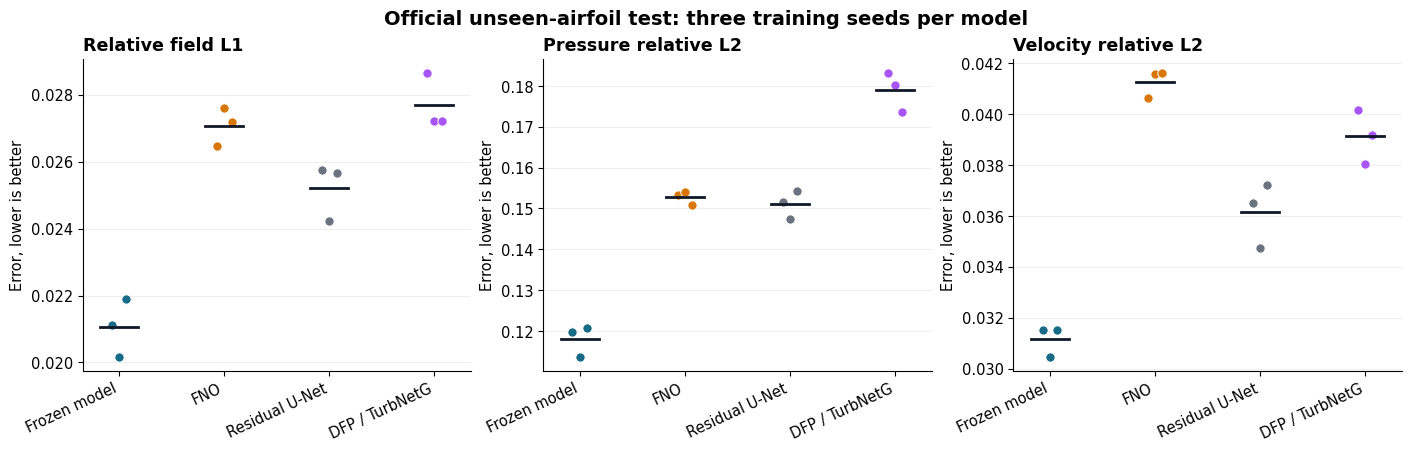

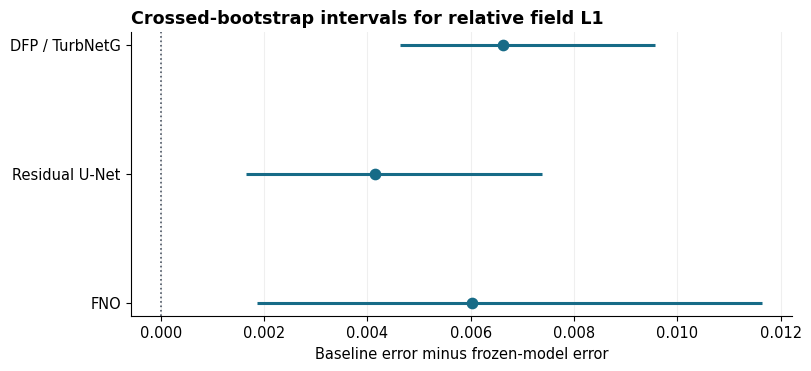

In [8]:
if ACTION != "audit":
    colors = {
        FINAL_MODEL: "#176B87",
        "fno": "#D97706",
        "modern_unet": "#6B7280",
        "dfp_original": "#A855F7",
    }

    figure_metrics = [
        (PRIMARY_METRIC, "Relative field L1"),
        (PRESSURE_GUARDRAIL, "Pressure relative L2"),
        (VELOCITY_GUARDRAIL, "Velocity relative L2"),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.4), constrained_layout=True)

    for axis, (metric, title) in zip(axes, figure_metrics):
        for x, name in enumerate(MODEL_ORDER):
            values = per_seed_metrics.loc[
                per_seed_metrics.experiment == name, metric
            ].to_numpy()
            jitter = np.linspace(-0.07, 0.07, len(values))
            axis.scatter(
                x + jitter,
                values,
                s=45,
                color=colors[name],
                edgecolor="white",
                linewidth=0.7,
                zorder=3,
            )
            axis.plot(
                [x - 0.18, x + 0.18],
                [values.mean(), values.mean()],
                color="#111827",
                linewidth=2,
                zorder=4,
            )
        axis.set_title(title, loc="left", fontweight="bold")
        axis.set_xticks(range(len(MODEL_ORDER)), [label_map[name] for name in MODEL_ORDER], rotation=25, ha="right")
        axis.set_ylabel("Error, lower is better")
        axis.grid(axis="y", alpha=0.2)

    fig.suptitle(
        "Official unseen-airfoil test: three training seeds per model",
        fontsize=14,
        fontweight="bold",
    )
    fig.savefig(TEST_ROOT / "figures" / "test_metrics_by_seed.png", dpi=220, bbox_inches="tight")
    fig.savefig(TEST_ROOT / "figures" / "test_metrics_by_seed.pdf", bbox_inches="tight")
    plt.show()

    interval_rows = pd.concat([
        primary_comparisons,
        secondary_comparisons[secondary_comparisons.metric == PRIMARY_METRIC],
    ], ignore_index=True)
    interval_rows = interval_rows[interval_rows.metric == PRIMARY_METRIC].copy()
    interval_rows["label"] = interval_rows.reference.map(label_map)

    fig, axis = plt.subplots(figsize=(8, 3.6), constrained_layout=True)
    y = np.arange(len(interval_rows))
    axis.hlines(
        y,
        interval_rows.absolute_ci95_low,
        interval_rows.absolute_ci95_high,
        color="#176B87",
        linewidth=2.2,
    )
    axis.scatter(interval_rows.absolute_improvement, y, color="#176B87", s=55, zorder=3)
    axis.axvline(0, color="#4B5563", linestyle=":", linewidth=1.2)
    axis.set_yticks(y, interval_rows.label)
    axis.set_xlabel("Baseline error minus frozen-model error")
    axis.set_title("Crossed-bootstrap intervals for relative field L1", loc="left", fontweight="bold")
    axis.grid(axis="x", alpha=0.2)
    fig.savefig(TEST_ROOT / "figures" / "test_primary_intervals.png", dpi=220, bbox_inches="tight")
    fig.savefig(TEST_ROOT / "figures" / "test_primary_intervals.pdf", bbox_inches="tight")
    plt.show()


## 6. Matched inference benchmark

Latency, throughput, peak incremental GPU memory, and parameter count are measured for one fixed seed per architecture in the same runtime. Resident FP32 tensors are used, and preprocessing plus host-to-device transfer are excluded. These measurements support engineering trade-off reporting, not accuracy claims.


In [9]:
timing_csv = TEST_ROOT / "matched_inference_timing.csv"
timing_receipt_path = TEST_ROOT / "matched_inference_receipt.json"

if ACTION == "audit":
    print("Timing is measured only after the sealed official evaluation.")
elif timing_csv.exists() or timing_receipt_path.exists():
    stage.require(timing_csv.exists() and timing_receipt_path.exists(), "Incomplete timing cache.")
    timing_receipt = stage.read_json(timing_receipt_path)
    stage.require(timing_receipt["plan_id"] == frozen_plan["plan_id"], "Timing plan mismatch.")
    timing_table = pd.read_csv(timing_csv)
    print("Reusing the matched inference benchmark.")
else:
    if not core.torch.cuda.is_available():
        raise RuntimeError("A GPU is required for the matched inference benchmark.")

    device = core.torch.device("cuda")
    timing_rows = []
    timing_hardware = core.torch.cuda.get_device_name(0)

    for name in MODEL_ORDER:
        seed = TIMING_SEED
        folder = run_root(name, seed)
        identity = identity_for(name, seed)
        checkpoint = core.torch.load(folder / "best.pt", map_location="cpu", weights_only=False)
        stage.require(checkpoint["run_id"] == identity["run_id"], "Timing checkpoint mismatch.")

        model = core.model_factory(identity["config"]).to(device)
        model.load_state_dict(checkpoint["model"])
        dataset = core.AirfoilDataset(
            PREPARED_ROOT,
            "test",
            range(metadata["test_samples"]),
            identity["condition_stats"],
            identity["config"],
        )

        for batch_size in TIMING_BATCH_SIZES:
            batch = next(iter(core.DataLoader(dataset, batch_size=batch_size, shuffle=False)))
            measured = core.benchmark_inference(
                model,
                batch,
                device,
                repeats=TIMING_REPEATS,
                warmup=TIMING_WARMUP,
            )
            timing_rows.append({
                "variant": name,
                "seed": seed,
                **measured,
            })

        del checkpoint, model, dataset
        gc.collect()
        core.torch.cuda.empty_cache()

    timing_table = pd.DataFrame(timing_rows)
    timing_table.to_csv(timing_csv, index=False)
    timing_receipt = {
        "plan_id": frozen_plan["plan_id"],
        "hardware": timing_hardware,
        "timing_scope": timing_table.timing_scope.iloc[0],
        "seed": TIMING_SEED,
        "batch_sizes": TIMING_BATCH_SIZES,
        "repeats": TIMING_REPEATS,
        "warmup": TIMING_WARMUP,
        "csv_sha256": stage.file_hash(timing_csv),
        "created_at_utc": datetime.now(timezone.utc).isoformat(),
    }
    stage.write_json(timing_receipt_path, timing_receipt)

display(timing_table.round(3) if ACTION != "audit" else pd.DataFrame())


,variant,seed,batch_size,median_batch_ms,p95_batch_ms,throughput_samples_per_sec,peak_incremental_bytes,timing_scope,hardware,real_scalar_parameters,parameter_bytes
0,no_alignment,42,1,15.008,16.540,66.201,42664960,"resident tensors, FP32 model forward, excludes...",Tesla T4,5690558,22762232
1,no_alignment,42,10,44.779,46.437,222.402,425460736,"resident tensors, FP32 model forward, excludes...",Tesla T4,5690558,22762232
2,fno,42,1,4.174,5.143,236.877,21570560,"resident tensors, FP32 model forward, excludes...",Tesla T4,5323251,21293004
3,fno,42,10,19.310,19.492,517.386,215441408,"resident tensors, FP32 model forward, excludes...",Tesla T4,5323251,21293004
4,modern_unet,42,1,2.617,2.828,379.305,18087936,"resident tensors, FP32 model forward, excludes...",Tesla T4,2061923,8247692
5,modern_unet,42,10,20.023,20.304,500.071,180879360,"resident tensors, FP32 model forward, excludes...",Tesla T4,2061923,8247692
6,dfp_original,42,1,2.350,2.844,413.678,29722624,"resident tensors, FP32 model forward, excludes...",Tesla T4,7736067,30944268
7,dfp_original,42,10,7.481,7.719,1329.947,97407488,"resident tensors, FP32 model forward, excludes...",Tesla T4,7736067,30944268


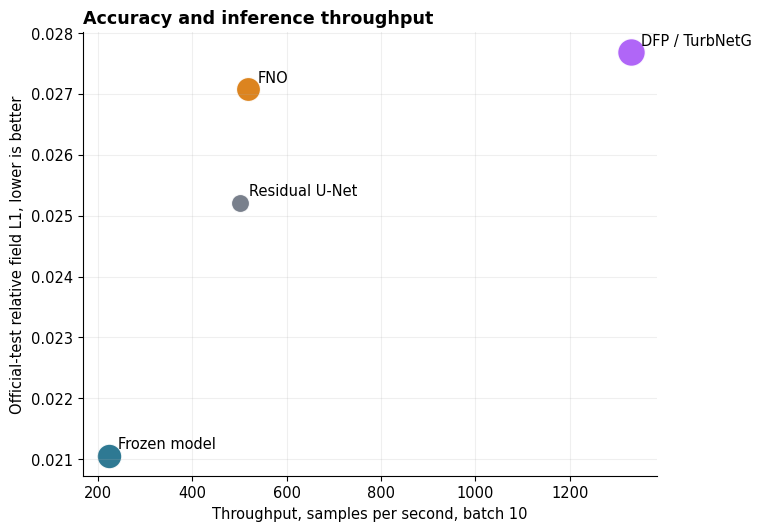

In [10]:
if ACTION != "audit":
    batch_timing = timing_table[timing_table.batch_size == 10].set_index("variant")
    accuracy = aggregate_metrics[(PRIMARY_METRIC, "mean")]

    fig, axis = plt.subplots(figsize=(7.5, 5.2), constrained_layout=True)
    for name in MODEL_ORDER:
        x = batch_timing.loc[name, "throughput_samples_per_sec"]
        y = accuracy.loc[name]
        size = 90 + 40 * batch_timing.loc[name, "real_scalar_parameters"] / 1_000_000
        axis.scatter(x, y, s=size, color=colors[name], alpha=0.9, edgecolor="white", linewidth=1)
        axis.annotate(label_map[name], (x, y), xytext=(7, 5), textcoords="offset points")

    axis.set_xlabel("Throughput, samples per second, batch 10")
    axis.set_ylabel("Official-test relative field L1, lower is better")
    axis.set_title("Accuracy and inference throughput", loc="left", fontweight="bold")
    axis.grid(alpha=0.2)
    fig.savefig(TEST_ROOT / "figures" / "accuracy_throughput_tradeoff.png", dpi=220, bbox_inches="tight")
    fig.savefig(TEST_ROOT / "figures" / "accuracy_throughput_tradeoff.pdf", bbox_inches="tight")
    plt.show()


## 7. Fixed qualitative cases

The three visualized samples were fixed in the plan from sorted identifiers before test prediction. They are not selected by test error. The plots compare the frozen model with the primary FNO baseline using the same seed.


,sample_id,airfoil_id,speed,flow_angle_deg
0,ag09_2028_-174,ag09,20.354911,-4.907994
45,goe147_2658_136,goe147,26.624166,2.939476
87,n64012a_4690_1752,n64012a,50.069179,20.486444


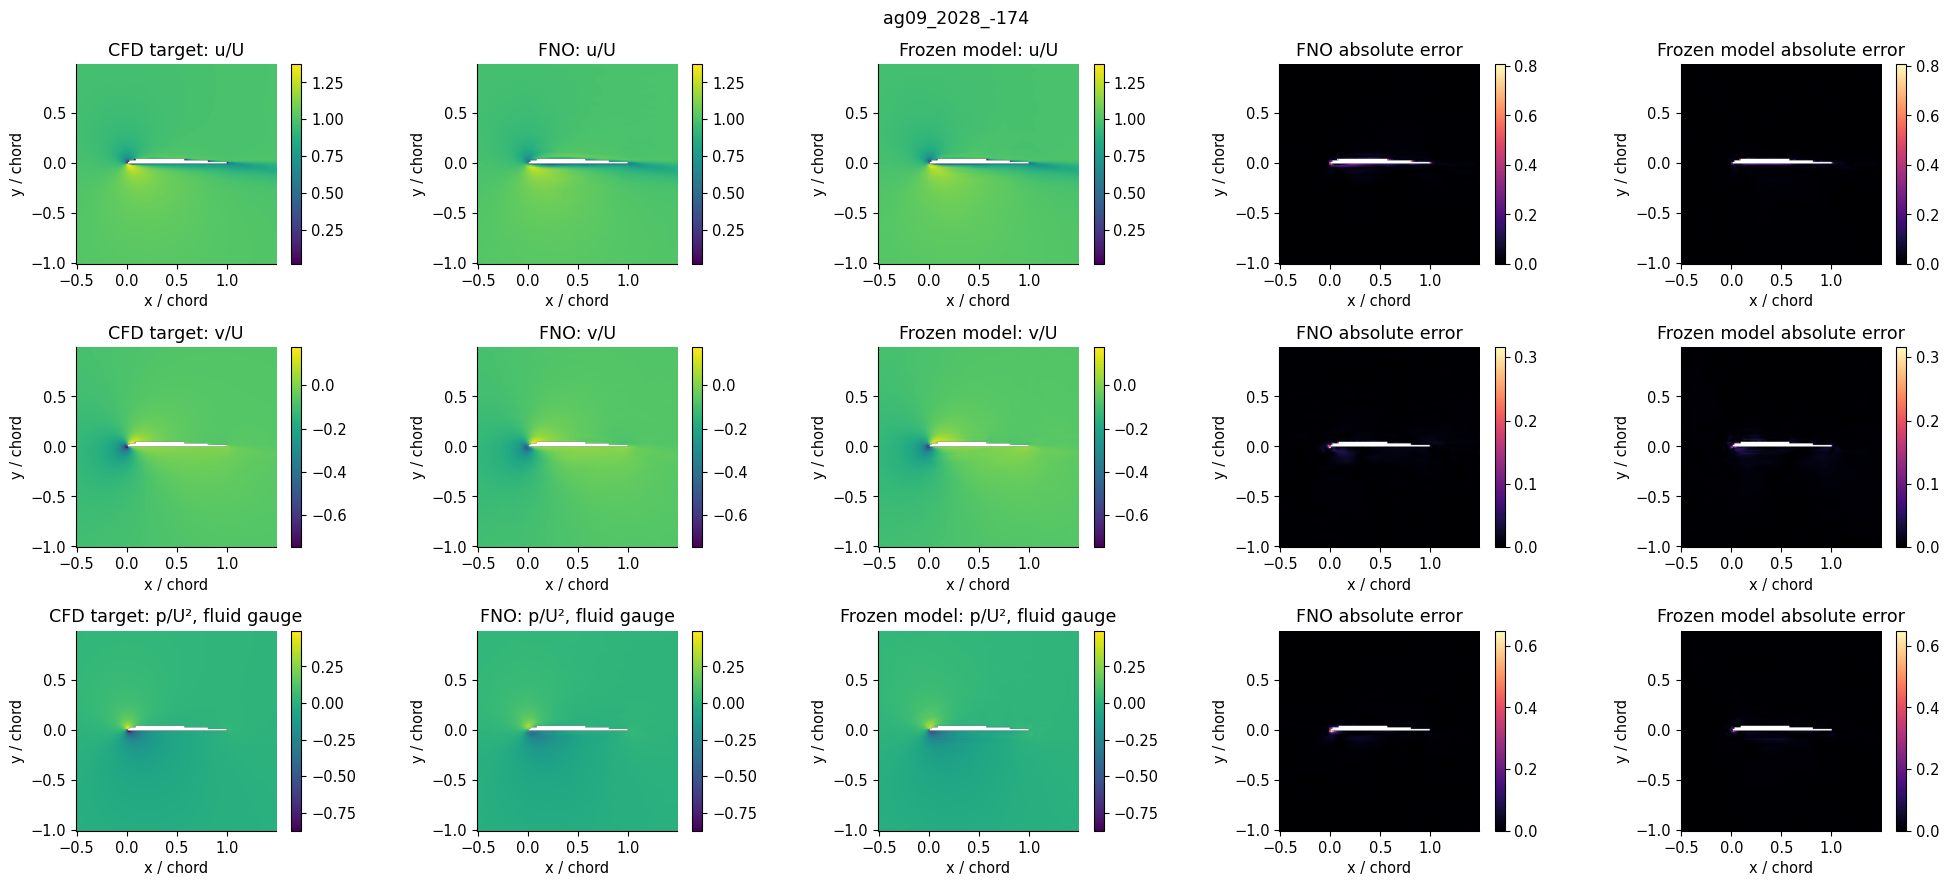

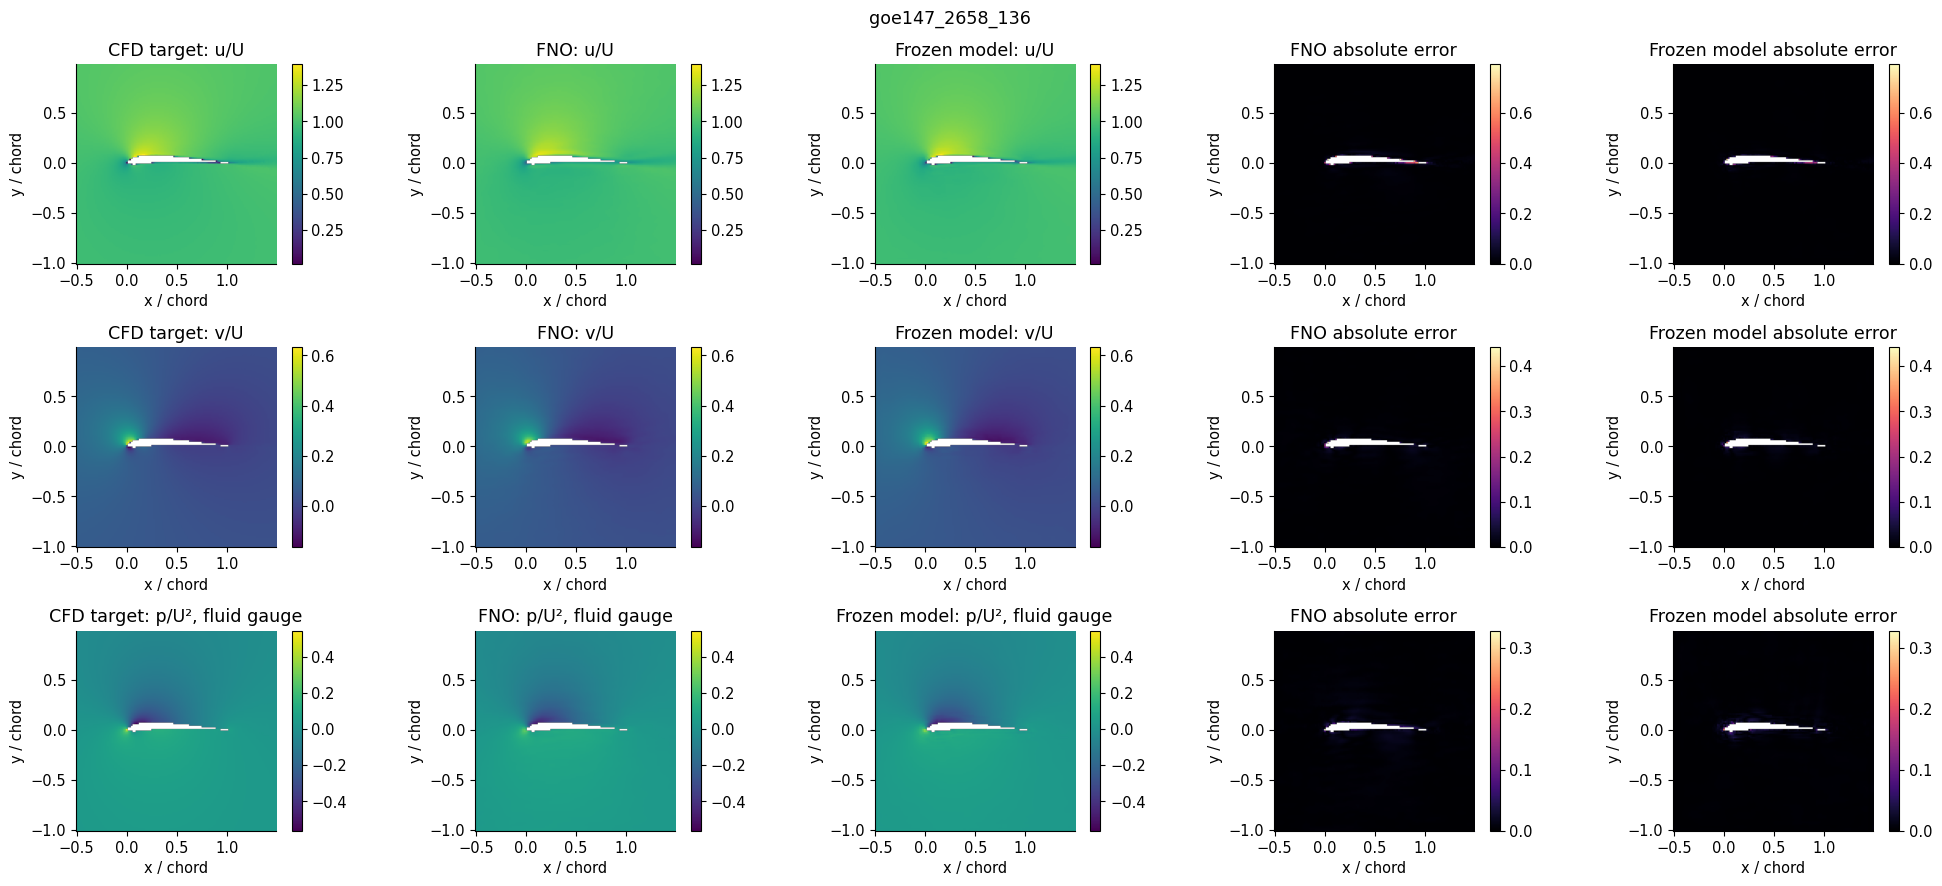

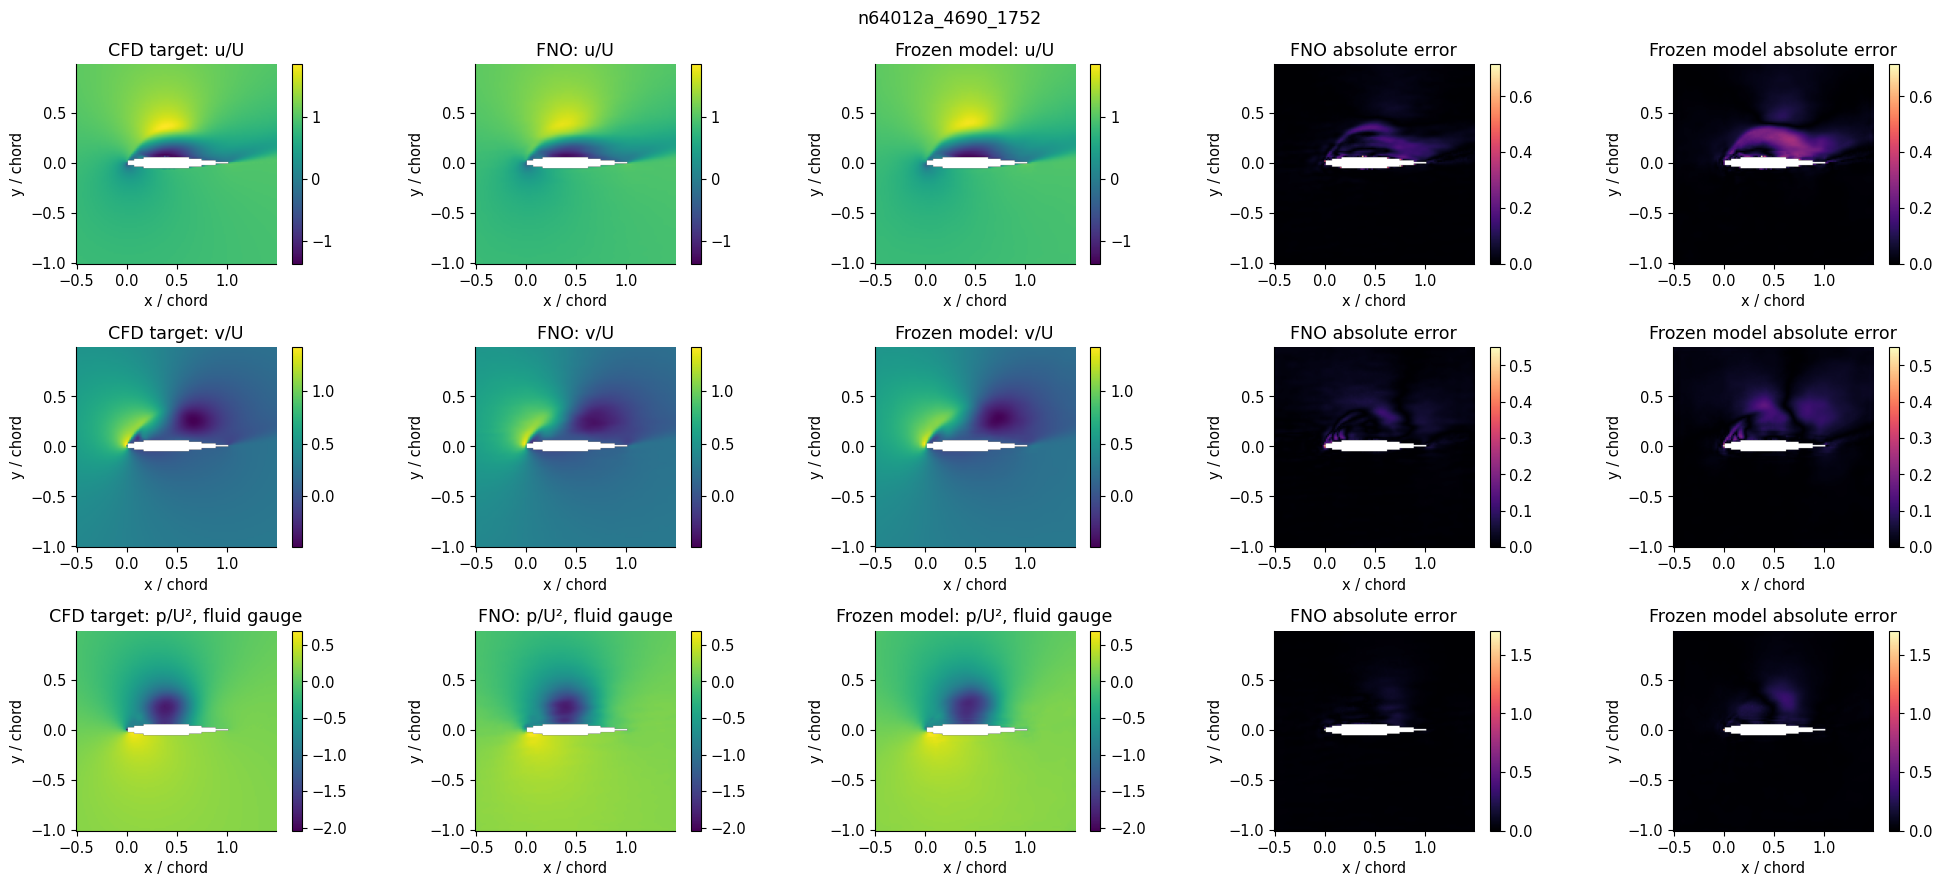

In [11]:
if ACTION == "audit":
    print("Qualitative figures require sealed official-test receipts.")
else:
    qualitative_selection = test_manifest[
        test_manifest.sample_id.isin(qualitative_sample_ids)
    ][[
        "sample_id", "airfoil_id", "speed", "flow_angle_deg"
    ]].sort_values("sample_id")
    qualitative_selection.to_csv(TEST_ROOT / "qualitative_case_selection.csv", index=False)
    display(qualitative_selection)

    core.plot_matched_predictions(
        PREPARED_ROOT,
        {
            "FNO": run_root(PRIMARY_BASELINE, QUALITATIVE_SEED),
            "Frozen model": run_root(FINAL_MODEL, QUALITATIVE_SEED),
        },
        qualitative_sample_ids,
        TEST_ROOT / "figures" / "qualitative",
    )


## 8. Publication handoff

The final cell writes compact manuscript tables, an explicit claim boundary, and a result manifest. Report the preregistered decision exactly as produced. A failed criterion is still a valid research result and must not trigger retraining or a new architecture selection on the official test set.


In [12]:
if ACTION != "audit":
    manuscript_rows = []
    for name in MODEL_ORDER:
        manuscript_rows.append({
            "model": label_map[name],
            "configuration": name,
            "relative_field_L1_mean": aggregate_metrics.loc[name, (PRIMARY_METRIC, "mean")],
            "relative_field_L1_std": aggregate_metrics.loc[name, (PRIMARY_METRIC, "std")],
            "pressure_relative_L2_mean": aggregate_metrics.loc[name, (PRESSURE_GUARDRAIL, "mean")],
            "pressure_relative_L2_std": aggregate_metrics.loc[name, (PRESSURE_GUARDRAIL, "std")],
            "velocity_relative_L2_mean": aggregate_metrics.loc[name, (VELOCITY_GUARDRAIL, "mean")],
            "velocity_relative_L2_std": aggregate_metrics.loc[name, (VELOCITY_GUARDRAIL, "std")],
            "parameters": int(batch_timing.loc[name, "real_scalar_parameters"]),
            "median_latency_ms_batch1": float(
                timing_table[(timing_table.variant == name) & (timing_table.batch_size == 1)]
                .median_batch_ms.iloc[0]
            ),
            "throughput_samples_per_sec_batch10": float(
                timing_table[(timing_table.variant == name) & (timing_table.batch_size == 10)]
                .throughput_samples_per_sec.iloc[0]
            ),
        })
    manuscript_table = pd.DataFrame(manuscript_rows)
    manuscript_table.to_csv(TEST_ROOT / "manuscript_official_test_table.csv", index=False)

    claim_boundary = {
        "plan_id": frozen_plan["plan_id"],
        "supported_if_primary_gate_passes": [
            "The frozen geometry-conditioned locally refined operator improves the preregistered primary unseen-airfoil metric relative to matched FNO.",
            "Pressure and velocity guardrail outcomes must be reported with the primary result.",
        ],
        "supported_from_validation_only": [
            "Removing local refinement worsened all four audited validation metrics in all three seeds.",
            "The specialized refiner showed a clear pressure advantage over a parameter-matched convolutional refiner control.",
        ],
        "not_supported": [
            "Flow alignment independently improves accuracy.",
            "Adaptive stencil weighting independently improves accuracy.",
            "The method is physics-informed or enforces the RANS equations.",
            "The official benchmark proves generalization beyond the evaluated dataset and Reynolds-number regime.",
        ],
        "primary_decision": primary_decision,
    }
    stage.write_json(TEST_ROOT / "publication_claim_boundary.json", claim_boundary)

    result_manifest = []
    for path in sorted(TEST_ROOT.rglob("*")):
        if path.is_file() and path.name != "result_manifest.json":
            result_manifest.append({
                "path": str(path.relative_to(TEST_ROOT)),
                "sha256": stage.file_hash(path),
                "bytes": path.stat().st_size,
            })
    stage.write_json(TEST_ROOT / "result_manifest.json", {
        "plan_id": frozen_plan["plan_id"],
        "files": result_manifest,
    })

    display(manuscript_table.round(6))
    print("\nPrimary decision:", primary_decision["interpretation"])
    print("Results folder:", TEST_ROOT)
    print("Manuscript table:", TEST_ROOT / "manuscript_official_test_table.csv")
    print("Claim boundary:", TEST_ROOT / "publication_claim_boundary.json")
else:
    print("Audit-only run complete. Change ACTION to 'evaluate' and rerun from the top once ready.")


,model,configuration,relative_field_L1_mean,relative_field_L1_std,pressure_relative_L2_mean,pressure_relative_L2_std,velocity_relative_L2_mean,velocity_relative_L2_std,parameters,median_latency_ms_batch1,throughput_samples_per_sec_batch10
0,Frozen model,no_alignment,0.021061,0.000865,0.118074,0.003821,0.031163,0.000603,5690558,15.007903,222.401624
1,FNO,fno,0.027080,0.000568,0.152762,0.001665,0.041274,0.000545,5323251,4.173967,517.385706
2,Residual U-Net,modern_unet,0.025213,0.000843,0.151121,0.003436,0.036155,0.001286,2061923,2.616909,500.070878
3,DFP / TurbNetG,dfp_original,0.027689,0.000830,0.179002,0.004856,0.039134,0.001057,7736067,2.350111,1329.946976



Primary decision: The preregistered unseen-airfoil superiority criterion was met.
Results folder: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_05/official_test_frozen_v1
Manuscript table: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_05/official_test_frozen_v1/manuscript_official_test_table.csv
Claim boundary: /content/drive/MyDrive/Colab Notebooks/Deep-Flow-Prediction/rans_airfoil_project/publication_v2/runs/study_05/official_test_frozen_v1/publication_claim_boundary.json
